In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DOWNLOADS_DIR = Path.home() / "Downloads"
prices = pd.read_csv(
     DOWNLOADS_DIR / "stock_prices.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

daily_returns = pd.read_csv(
    DOWNLOADS_DIR/"daily_returns.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

In [6]:
# geometric annual return(252 days because indian stocks trade approx 252 days in a year)
annual_returns = ((1 + daily_returns).prod() ** (252 / len(daily_returns))) - 1
annual_returns

HDFC Bank    0.103473
Infosys      0.168969
Reliance     0.182046
HUL          0.054657
dtype: float64

In [7]:
#daily risk
daily_volatility = daily_returns.std()

daily_volatility

HDFC Bank    0.015695
Infosys      0.017300
Reliance     0.017699
HUL          0.014213
dtype: float64

In [8]:
#annualised volatility
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

HDFC Bank    0.249157
Infosys      0.274632
Reliance     0.280966
HUL          0.225627
dtype: float64

In [9]:
#risk summary table
risk_return = pd.DataFrame({

    "Annual Return": annual_returns,

    "Annual Volatility": annual_volatility

})

risk_return

,Annual Return,Annual Volatility
HDFC Bank,0.103473,0.249157
Infosys,0.168969,0.274632
Reliance,0.182046,0.280966
HUL,0.054657,0.225627


In [10]:
# Assumed annual risk-free rate (6%)
risk_free_rate = 0.06

In [11]:
#sharpe ratio
sharpe_ratio = (

annual_returns - risk_free_rate

) / annual_volatility

sharpe_ratio

HDFC Bank    0.174480
Infosys      0.396780
Reliance     0.434381
HUL         -0.023681
dtype: float64

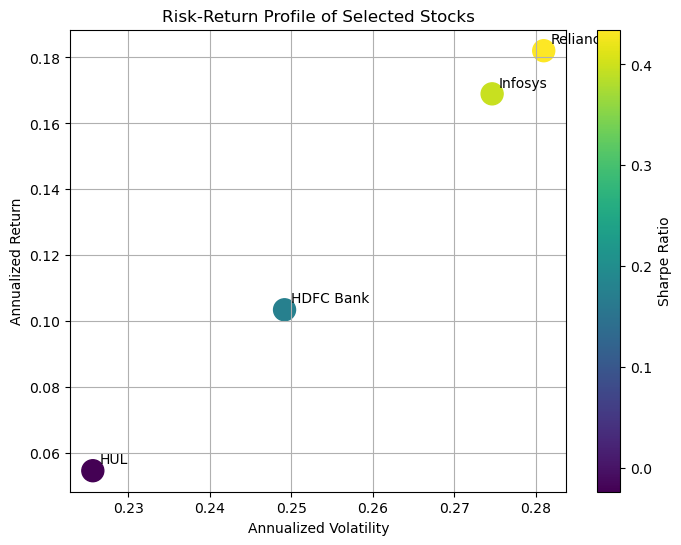

In [12]:
#risk-return plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    annual_volatility,
    annual_returns,
    c=sharpe_ratio,
    s=250
)

for stock in risk_return.index:
    plt.annotate(
        stock,
        (
            risk_return.loc[stock, "Annual Volatility"],
            risk_return.loc[stock, "Annual Return"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk-Return Profile of Selected Stocks")
plt.grid(True)

plt.show()

In [13]:
#updated summary table
risk_return["Sharpe Ratio"] = sharpe_ratio

risk_return.round(3)

,Annual Return,Annual Volatility,Sharpe Ratio
HDFC Bank,0.103,0.249,0.174
Infosys,0.169,0.275,0.397
Reliance,0.182,0.281,0.434
HUL,0.055,0.226,-0.024


In [14]:
#cumulative returns
cumulative_returns = (

1 + daily_returns

).cumprod()

In [15]:
risk_return["Coefficient of Variation"] = (
    annual_volatility / annual_returns
)
risk_return.round(3)

,Annual Return,Annual Volatility,Sharpe Ratio,Coefficient of Variation
HDFC Bank,0.103,0.249,0.174,2.408
Infosys,0.169,0.275,0.397,1.625
Reliance,0.182,0.281,0.434,1.543
HUL,0.055,0.226,-0.024,4.128


In [16]:
#rank stocks by sharpe ratio
risk_return = risk_return.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

risk_return

,Annual Return,Annual Volatility,Sharpe Ratio,Coefficient of Variation
Reliance,0.182046,0.280966,0.434381,1.543376
Infosys,0.168969,0.274632,0.396780,1.625344
HDFC Bank,0.103473,0.249157,0.174480,2.407946
HUL,0.054657,0.225627,-0.023681,4.128052


In [17]:
cumulative_returns.head()

,HDFC Bank,Infosys,Reliance,HUL
Date,,,,
2019-01-02,0.990876,1.006015,0.986976,0.990839
2019-01-03,0.983101,1.006165,0.974799,0.992949
2019-01-04,0.985731,0.993985,0.980062,0.989229
2019-01-07,0.987221,1.009999,0.985504,0.991033
2019-01-08,0.979005,1.007518,0.985415,0.983205


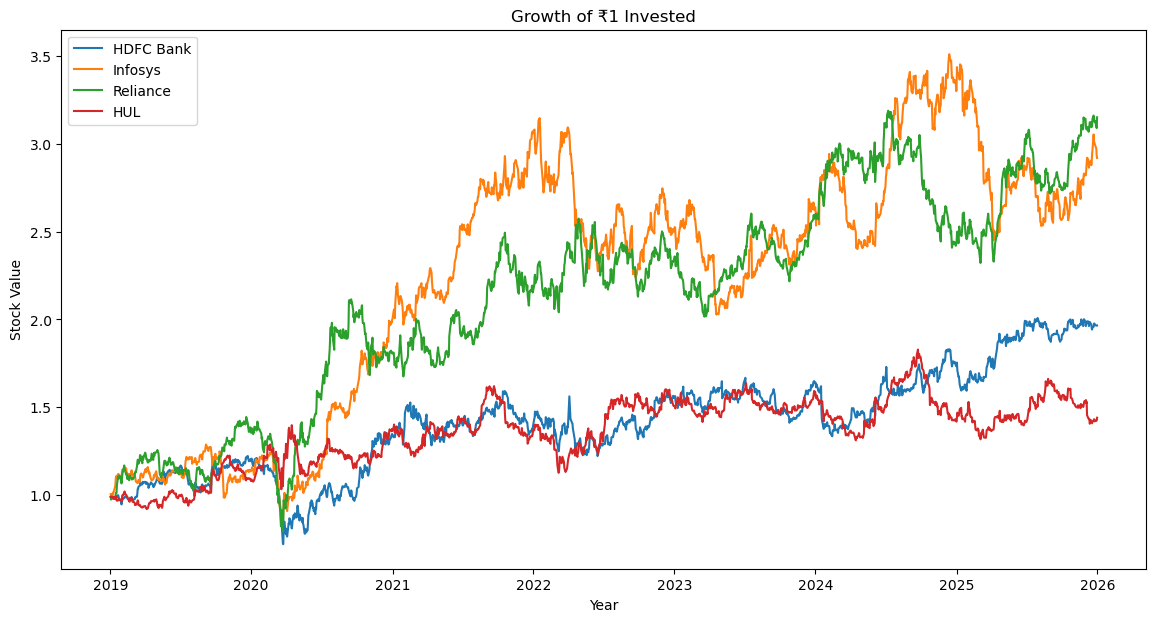

In [18]:
plt.figure(figsize=(14,7))

for stock in cumulative_returns.columns:

    plt.plot(

        cumulative_returns.index,

        cumulative_returns[stock],

        label=stock

    )

plt.legend()

plt.title("Growth of ₹1 Invested")

plt.xlabel("Year")

plt.ylabel("Stock Value")

plt.show()